# Layer 3 (PFF): RQ3 part 1, what could the passer see and remember?

RQ3 is answered here with the PFF tracking data, which fixes the three weaknesses of the StatsBomb version:

| | StatsBomb 360 version | PFF version |
|---|---|---|
| Player identity | none; freeze frames linked into anonymous tracks (about 91% correct off the ball) | every player identified |
| History | only the freeze frames, one per event (median 0.73 s apart) | continuous, sampled here at 10 per second |
| What counts as memory | anywhere on camera in the last 2 s (predictability, an upper bound) | **inside the passer's own vision cone** in the last 5 s |

The last row is the important one. With continuous tracking, the passer's 120 degree cone can be rebuilt at every moment before the pass, exactly as in Layer 1: centred on the passer's direction of movement. A teammate counts as **seen** at a moment if they were inside the cone at that moment. For a teammate outside the cone when the pass is played, the **memory history** is the list of moments in the previous 5 seconds when the passer saw them. That is the only information a memory could hold, so this measures memory directly rather than predictability.

This notebook:

1. extracts the tracking of all 64 games into compact arrays at 10 per second (also used later for the demo);
2. builds, for every PFF pass, each teammate's cone status at the pass and their seen history;
3. checks the cone against where passes actually go;
4. describes how much memory history unseen teammates have;
5. sets the memory threshold tau from the width of defensive lines, as the proposal specifies.

The next notebook trains the LSTM on these histories and answers RQ3.

Positions are in metres, rotated so the passing team attacks toward +x, with the origin at the centre spot. Code: `src/pff_memory.py` and `src/pff.py`.

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")


import sys, os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'src'))
import importlib
import pff, pff_memory
importlib.reload(pff)
importlib.reload(pff_memory)

RESULTS = Path('../data/results')
ARR_DIR = Path('../data/pff_arrays')
ARR_DIR.mkdir(parents=True, exist_ok=True)

meta = pff.load_metadata().set_index('pff_game_id')
pff_all = pd.read_pickle(RESULTS / 'pff_passes_all.pkl')
gids = list(meta.index)
print(len(gids), 'games,', len(pff_all), 'PFF passes and crosses')

64 games, 69127 PFF passes and crosses


## 1. Tracking arrays for every game

Each tracking file is read once and stored as arrays (positions, PFF visibility flag and ball) at 10 samples per second, with players identified through the roster. Each game uses about 10 MB on disk. Games already extracted are skipped.

In [2]:
t0 = time.time()
for i, gid in enumerate(gids):
    path = ARR_DIR / f'arrays_{gid}.npz'
    if path.exists():
        continue
    arr = pff.extract_match_arrays(gid)
    np.savez_compressed(path, **arr)
    print(f"[{i + 1}/{len(gids)}] game {gid}: {arr['xy'].shape[0]} samples, {arr['xy'].shape[1]} players "
          f"({time.time() - t0:.0f}s)")
print('all games extracted')

[1/64] game 3812: 61951 samples, 30 players (26s)
[2/64] game 3813: 70422 samples, 33 players (55s)
[3/64] game 3814: 60362 samples, 28 players (78s)
[4/64] game 3815: 62662 samples, 31 players (101s)
[5/64] game 3816: 66325 samples, 31 players (125s)
[6/64] game 3817: 61297 samples, 31 players (148s)
[7/64] game 3818: 59740 samples, 28 players (170s)
[8/64] game 3819: 62142 samples, 32 players (196s)
[9/64] game 3820: 58947 samples, 30 players (218s)
[10/64] game 3821: 62448 samples, 32 players (241s)
[11/64] game 3822: 61973 samples, 32 players (264s)
[12/64] game 3823: 60089 samples, 31 players (291s)
[13/64] game 3824: 59604 samples, 31 players (315s)
[14/64] game 3825: 59588 samples, 29 players (342s)
[15/64] game 3826: 61368 samples, 32 players (365s)
[16/64] game 3827: 59020 samples, 32 players (389s)
[17/64] game 3828: 64160 samples, 31 players (412s)
[18/64] game 3829: 61983 samples, 31 players (436s)
[19/64] game 3830: 60324 samples, 29 players (458s)
[20/64] game 3831: 57660

## 2. Cone status and seen history for every pass

For each PFF pass and cross:

- the passer's heading is their direction of movement over the last 0.5 s. If they are almost standing still (under 1 m/s), the last heading from up to 2 s earlier is kept. If there is none, the heading falls back to facing the opponent goal, and this is flagged.
- each teammate is inside or outside the 120 degree cone at the pass;
- for teammates outside the cone, the moments in the previous 5 s when they were inside the passer's cone are collected. The most recent 20 are kept as the memory history.

In [3]:
t0 = time.time()
mate_parts, hist_parts = [], []
for gid in gids:
    arr = dict(np.load(ARR_DIR / f'arrays_{gid}.npz'))
    mates, hist = pff_memory.build_examples(arr, pff_all[pff_all['pff_game_id'] == gid], meta.loc[gid, 'fps'])
    mate_parts.append(mates)
    hist_parts.append(hist)
mates = pd.concat(mate_parts, ignore_index=True)
hist = np.concatenate(hist_parts)
assert len(mates) == len(hist)
print(f'{time.time() - t0:.0f}s')

n_pass = mates['possession_event_id'].nunique()
per_pass = mates.groupby('possession_event_id').first()
print(f"{n_pass} passes ({n_pass / len(pff_all):.1%} of PFF passes and crosses), {len(mates)} teammate rows "
      f"({len(mates) / n_pass:.2f} per pass)")
print(f"heading fell back to facing the opponent goal: {per_pass['heading_fallback'].mean():.1%} of passes")
print(f"teammates inside the cone at the pass: {mates['in_cone'].mean():.1%}")
print(f"teammates tracked on camera (VISIBLE) at the pass: {mates['target_visible'].mean():.1%}")

97s
68467 passes (99.0% of PFF passes and crosses), 684675 teammate rows (10.00 per pass)
heading fell back to facing the opponent goal: 4.3% of passes
teammates inside the cone at the pass: 32.7%
teammates tracked on camera (VISIBLE) at the pass: 53.8%


**What this shows**

All 64 games are extracted, 587 MB in total. Cone status and seen history were built for 68467 passes and crosses, 99.0 percent of PFF's total; the rest have the passer missing from the tracking at that moment. That gives 684675 teammate rows, exactly 10 per pass, since PFF tracks every player.

**The heading is almost always available.** It had to fall back to facing the opponent goal for only 4.3 percent of passes, where the passer had not moved faster than 1 m/s in the previous 2 s.

**The cone covers about a third of teammates.** 32.7 percent are inside it at the pass, close to the StatsBomb figure of 34.5 percent among freeze-frame teammates.

**Ground truth is available for about half.** 53.8 percent of teammates are tracked on camera (VISIBLE) at the pass. Only those are used as targets when scoring predictions.

## 3. Does the cone match where passes go?

If the cone captures what the passer can see, receivers of completed passes should be inside it far more often than a random teammate. This compares the receiver's share inside the cone with the share of all teammates inside the cone on the same passes. The interval resamples whole games.

The StatsBomb version gave 52.3 percent against 34.5 percent expected.

In [4]:
def game_bootstrap(df, col_obs, col_exp, n_boot=5000, seed=0):
    g = df.groupby('pff_game_id').agg(o=(col_obs, 'sum'), e=(col_exp, 'sum'), n=(col_obs, 'size'))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(g), size=(n_boot, len(g)))
    o, e, n = g['o'].to_numpy()[idx].sum(1), g['e'].to_numpy()[idx].sum(1), g['n'].to_numpy()[idx].sum(1)
    d = (o - e) / n
    return g['o'].sum() / g['n'].sum(), g['e'].sum() / g['n'].sum(), np.percentile(d, [2.5, 97.5])


share_in_cone = mates.groupby('possession_event_id')['in_cone'].mean().rename('expected_in_cone')
rec = mates[mates['is_receiver'] & mates['complete']].join(share_in_cone, on='possession_event_id')
obs, exp, ci = game_bootstrap(rec, 'in_cone', 'expected_in_cone')
print(f"{len(rec)} completed passes with an identified receiver")
print(f"receiver inside the cone: {obs:.1%}, expected for a random teammate: {exp:.1%}, "
      f"difference {100 * (obs - exp):+.1f} points (95% CI {100 * ci[0]:+.1f} to {100 * ci[1]:+.1f})")
print(f"blind passes (receiver outside the cone): {(~rec['in_cone']).sum()} ({(~rec['in_cone']).mean():.1%})")

55641 completed passes with an identified receiver
receiver inside the cone: 59.2%, expected for a random teammate: 33.2%, difference +26.0 points (95% CI +25.0 to +27.1)
blind passes (receiver outside the cone): 22696 (40.8%)


**What this shows**

**The cone tracks where passes go, slightly more strongly than in the StatsBomb version.** In 55641 completed passes with an identified receiver, the receiver is inside the passer's cone 59.2 percent of the time. A random teammate on the same passes would be inside it 33.2 percent of the time. That is a difference of +26.0 points (95 percent CI +25.0 to +27.1, resampling games). The StatsBomb version gave 52.3 against 34.5 percent (+17.8). The PFF version uses the same rule, but continuous tracking gives a cleaner movement direction than the previous-touch vector.

**About four passes in ten are blind passes.** 22696 completed passes (40.8 percent) go to a receiver outside the cone. These are the passes RQ3 is about: if the passer could not see the receiver, did they know where the receiver was?

As in the StatsBomb version, the cone is built from movement direction, not head direction. Players scan, so some "blind" receivers will have been glanced at. Section 4 measures how recently the passer could have seen them.

## 4. How much memory do unseen teammates have?

For teammates outside the cone at the pass, a teammate has a memory history if the passer saw them at least once in the previous 5 s. Shown for all unseen teammates and for the receivers of blind passes. The time since last seen matters, because positions drift the longer a teammate is out of view.

In [5]:
out = mates[~mates['in_cone']].copy()
out['has_memory'] = out['n_seen'].fillna(0) > 0
blind = out[out['is_receiver'] & out['complete']]
for name, d in [('all teammates outside the cone', out), ('receivers of blind passes', blind)]:
    m = d[d['has_memory']]
    print(f"{name}: {len(d)}")
    print(f"  seen by the passer in the last 5 s: {d['has_memory'].mean():.1%}")
    print(f"  time since last seen (s): median {m['gap_s'].median():.2f}, quartiles "
          f"{m['gap_s'].quantile(0.25):.2f} to {m['gap_s'].quantile(0.75):.2f}")
    print(f"  seen samples: median {m['n_seen'].median():.0f}")
    print(f"  tracked on camera at the pass (usable as ground truth): {d['target_visible'].mean():.1%}")

m = out[out['has_memory']]
drift = np.hypot(m['x'] - m['last_x'], m['y'] - m['last_y'])
m = m.assign(drift=drift, gap_band=pd.cut(m['gap_s'], [0, 0.5, 1, 2, 3, 5], include_lowest=True))
print()
print('distance moved since last seen (m), by time since last seen (VISIBLE targets only):')
print(m[m['target_visible']].groupby('gap_band', observed=True)['drift'].describe()[['count', 'mean', '50%']].round(2))

all teammates outside the cone: 460469
  seen by the passer in the last 5 s: 49.4%
  time since last seen (s): median 1.84, quartiles 0.83 to 3.20
  seen samples: median 15
  tracked on camera at the pass (usable as ground truth): 52.3%
receivers of blind passes: 22696
  seen by the passer in the last 5 s: 54.0%
  time since last seen (s): median 1.63, quartiles 0.70 to 3.00
  seen samples: median 16
  tracked on camera at the pass (usable as ground truth): 66.5%

distance moved since last seen (m), by time since last seen (VISIBLE targets only):
                 count  mean   50%
gap_band                          
(-0.001, 0.5]  18848.0  0.64  0.44
(0.5, 1.0]     21528.0  1.62  1.25
(1.0, 2.0]     31628.0  3.10  2.46
(2.0, 3.0]     24158.0  4.99  4.07
(3.0, 5.0]     36349.0  7.49  6.25


**What this shows**

**About half of unseen teammates were seen by the passer in the previous 5 s.** Of 460469 teammates outside the cone at the pass:

- 49.4 percent were inside the passer's cone at least once in the 5 s before;
- they were last seen a median of 1.84 s before the pass (quartiles 0.83 to 3.20 s);
- they were seen for a median of 15 samples (1.5 s of viewing).

**Receivers of blind passes were seen more, and more recently, than other unseen teammates.** 54.0 percent were seen in the last 5 s, last seen a median of 1.63 s before the pass. This is a first sign that blind passes go to teammates the passer had recently looked at. The next notebook tests it properly, within the same passes.

**Memory fades quickly.** The distance a teammate moved since they were last seen grows with the time since:

| Time since last seen | Median distance moved |
|---|---|
| 0 to 0.5 s | 0.44 m |
| 0.5 to 1 s | 1.25 m |
| 1 to 2 s | 2.46 m |
| 2 to 3 s | 4.07 m |
| 3 to 5 s | 6.25 m |

So "assume they have not moved" works for a teammate seen half a second ago, but not for one last seen 3 s ago. That is the gap the LSTM has to close.

About half of these teammates (52.3 percent, and 66.5 percent of blind receivers) are tracked on camera at the pass. Only those can be used to score a prediction.

## 5. Setting tau from defensive line widths

The proposal sets the memory threshold tau "from the distribution of defensive line widths". Here that is measured directly:

- **When:** once a second, for each team defending in its own half.
- **What:** the lateral gaps between the four deepest outfield players, using only moments when all four are tracked on camera.

A remembered position that is wrong by less than half the typical gap still places the teammate in the right channel between two defenders. So half the median gap is used as tau.

407634 gaps measured
gap between neighbouring back-line players: quartiles 5.8, median 9.3, 13.6 m
tau = half the median gap = 4.66 m


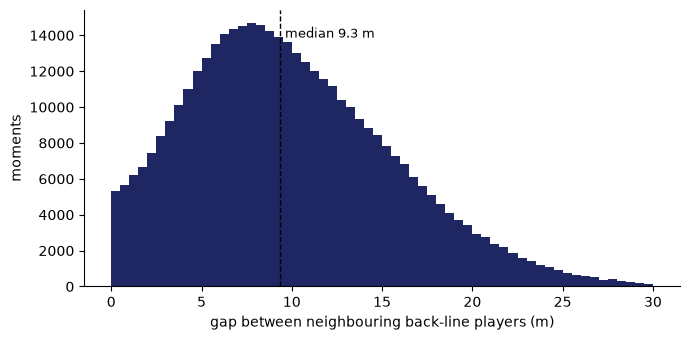

In [6]:
gaps = []
for gid in gids:
    arr = dict(np.load(ARR_DIR / f'arrays_{gid}.npz'))
    ro = pff.load_roster(gid)
    gk = set(ro.loc[ro['position_group'] == 'GK', 'pff_player_id'])
    gaps.append(pff_memory.back_line_gaps(arr, bool(meta.loc[gid, 'home_start_left']), gk))
gaps = np.concatenate(gaps)
TAU = float(np.median(gaps) / 2)
print(f"{len(gaps)} gaps measured")
print(f"gap between neighbouring back-line players: quartiles {np.percentile(gaps, 25):.1f}, "
      f"median {np.median(gaps):.1f}, {np.percentile(gaps, 75):.1f} m")
print(f"tau = half the median gap = {TAU:.2f} m")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(gaps, bins=np.arange(0, 30.5, 0.5), color='#1E2761')
ax.axvline(np.median(gaps), color='black', ls='--', lw=1)
ax.text(np.median(gaps) + 0.3, ax.get_ylim()[1] * 0.9, f'median {np.median(gaps):.1f} m', fontsize=9)
ax.set_xlabel('gap between neighbouring back-line players (m)')
ax.set_ylabel('moments')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(plt.gcf(), 'rq3_pff_backline_gaps.png')
plt.show()

**What this shows**

**tau = 4.66 m, measured from the data as the proposal specifies.** Over 407634 measurements, neighbouring players in a defending back line are a median 9.3 m apart (quartiles 5.8 and 13.6 m). A remembered position that is wrong by less than half of that, 4.66 m, still puts the teammate in the right channel between two defenders. It is close to the 4 m used in the StatsBomb version and inside the 3 to 5 m range set in the proposal, so the earlier choice is supported by the data. The next notebook uses 4.66 m as tau, with an ablation from 3 to 6 m.

## 6. Save

In [7]:
mates.to_pickle(RESULTS / 'pff_memory_mates.pkl')
np.save(RESULTS / 'pff_memory_hist.npy', hist)
json.dump({'tau_m': TAU, 'median_gap_m': float(np.median(gaps)), 'n_gaps': int(len(gaps))},
          open(RESULTS / 'pff_tau.json', 'w'), indent=1)
print('saved pff_memory_mates.pkl, pff_memory_hist.npy, pff_tau.json')

saved pff_memory_mates.pkl, pff_memory_hist.npy, pff_tau.json


## Summary

**PFF lets RQ3 measure memory directly.** The passer's 120 degree cone was rebuilt ten times a second in the 5 s before each of 68467 passes. Memory is defined as the moments a teammate was actually inside that cone, not just on camera.

**The cone tracks passing choices.** Receivers are inside it 59.2 percent of the time against 33.2 percent for a random teammate (+26.0 points, 95 percent CI +25.0 to +27.1). That is stronger than the StatsBomb version (+17.8).

**Blind passes are common.** 40.8 percent of completed passes (22696) go to a receiver outside the cone.

**Memory is available for about half of unseen teammates.**

- 49.4 percent were seen in the previous 5 s, a median 1.84 s before the pass.
- Blind-pass receivers were seen more often (54.0 percent) and more recently (1.63 s).
- How far a teammate moves since last seen grows quickly: from 0.4 m after half a second to 6.3 m after 3 to 5 s.

**tau comes from the data: 4.66 m,** half the median gap between neighbouring back-line players (9.3 m). This supports the 4 m used earlier.

Saved:

- `pff_memory_mates.pkl`: one row per teammate per pass;
- `pff_memory_hist.npy`: seen histories, aligned with the rows;
- `pff_tau.json`;
- the per-game tracking arrays in `data/pff_arrays/`.

**Next:** train the LSTM on the seen histories and answer RQ3. How many blind passes went to a teammate whose position the passer could have remembered to within tau?